# Airbnb Paris — Prédiction du prix d'une nuitée

**Projet final M102 · NEEKOCODE · IPSSI**

## Problème métier
Une plateforme de location courte durée veut **aider ses hôtes parisiens à fixer le bon prix**.
- Trop bas → manque à gagner
- Trop haut → l'annonce ne se loue pas

**Mission** : prédire le prix d'une nuitée à partir des caractéristiques d'un logement (quartier, type, capacité, équipements, hôte, reviews).

## Plan
1. Loading + EDA
2. Cleaning (`price`, `amenities`, `bathrooms_text`)
3. Feature engineering (≥5 features amenities booléennes)
4. Pipeline anti-fuite (`ColumnTransformer` + `TransformedTargetRegressor` log1p)
5. Comparaison ≥3 modèles en CV 5-fold (R², MAE)
6. Tuning léger + évaluation test set + résidus
7. Démo prédiction sur un cas concret
8. Export `model.joblib` + `metrics.json`

## 1. Imports & configuration

In [1]:
import os, logging
os.environ['PYTHONWARNINGS'] = 'ignore'
logging.getLogger().setLevel(logging.ERROR)
import ast
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RNG = 42
DATA_PATH = Path('listings.csv')
print(f'pandas {pd.__version__} | scikit-learn imported')

pandas 3.0.3 | scikit-learn imported


## 2. Loading & EDA brute

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'shape: {df_raw.shape}')
df_raw.head(3)

shape: (84055, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3109,https://www.airbnb.com/rooms/3109,20250606142312,2025-06-20,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,5.00,5.00,5.00,7511409139079,f,1,1,0,0,0.08
1,5396,https://www.airbnb.com/rooms/5396,20250606142312,2025-06-19,city scrape,Your perfect Paris studio on Île Saint-Louis,"Cozy, well-appointed and graciously designed s...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,4.85,4.95,4.59,7510402838018,f,1,1,0,0,2.32
2,7397,https://www.airbnb.com/rooms/7397,20250606142312,2025-06-20,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,4.89,4.94,4.74,7510400829623,f,1,1,0,0,2.20


In [3]:
# Aperçu types et NA sur les colonnes candidates
candidates = [
    'price', 'neighbourhood_cleansed', 'room_type', 'property_type',
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 'bathrooms_text',
    'amenities', 'latitude', 'longitude',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_location', 'review_scores_cleanliness',
    'host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
    'instant_bookable', 'reviews_per_month',
]
missing = df_raw[candidates].isna().mean().sort_values(ascending=False).round(3)
missing.to_frame('na_rate')

,na_rate
host_response_rate,0.373
price,0.358
beds,0.357
bathrooms,0.354
host_acceptance_rate,0.311
review_scores_location,0.233
review_scores_cleanliness,0.233
review_scores_rating,0.233
reviews_per_month,0.233
bedrooms,0.085


## 3. Cleaning

### 3.1 Parser `price` (`"$120.00"` → `float`)

In [4]:
def parse_price(s):
    """'$1,234.50' -> 1234.5. NaN -> NaN."""
    if pd.isna(s):
        return np.nan
    return float(str(s).replace('$', '').replace(',', '').strip())

df = df_raw.copy()
df['price'] = df['price'].apply(parse_price)
print('price stats:')
print(df['price'].describe().round(2))
print(f'NA price: {df["price"].isna().sum()} / {len(df)}')

price stats:
count    53963.00
mean       285.26
std        688.62
min          8.00
25%        104.00
50%        161.00
75%        277.00
max      30814.00
Name: price, dtype: float64
NA price: 30092 / 84055


In [5]:
# Suppression annonces sans prix ou prix aberrants (0 ou > Q98)
# Q98 plutôt que Q99 : les ~2% du haut sont des hôtels de luxe / arnaques qui plombent la MAE absolue
before = len(df)
df = df[df['price'].notna() & (df['price'] > 0)].copy()
q98 = df['price'].quantile(0.98)
df = df[df['price'] <= q98].copy()
print(f'Lignes: {before} -> {len(df)} (Q98 = {q98:.0f} €)')

Lignes: 84055 -> 52883 (Q98 = 1201 €)


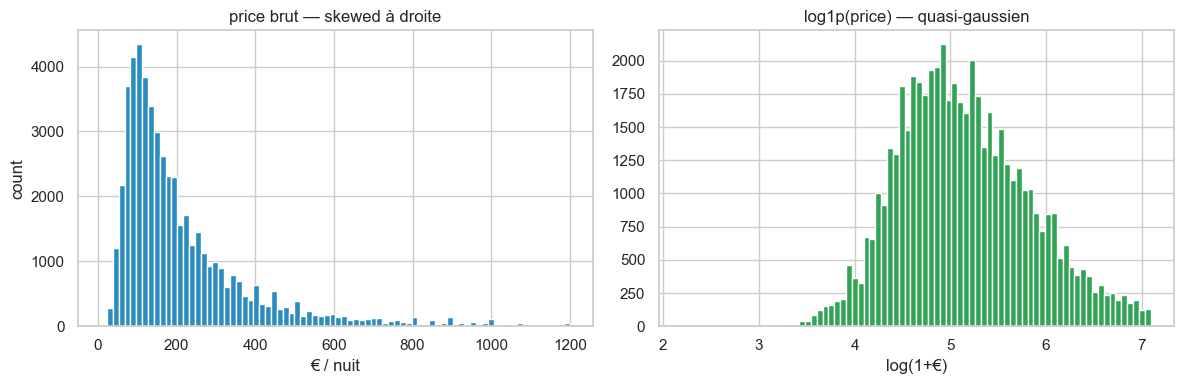

skew brut: 2.26 | skew log1p: 0.37


In [6]:
# Distribution du prix : brut vs log1p
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=80, color='#2b8cbe')
axes[0].set_title('price brut — skewed à droite')
axes[0].set_xlabel('€ / nuit'); axes[0].set_ylabel('count')
axes[1].hist(np.log1p(df['price']), bins=80, color='#31a354')
axes[1].set_title('log1p(price) — quasi-gaussien')
axes[1].set_xlabel('log(1+€)')
plt.tight_layout(); plt.show()
print(f'skew brut: {df["price"].skew():.2f} | skew log1p: {np.log1p(df["price"]).skew():.2f}')

**Observation** : `price` est fortement skewed à droite (skew >> 0). On utilisera `TransformedTargetRegressor(log1p, expm1)` pour entraîner sur l'échelle log et restituer les prédictions en €.

### 3.2 Parser `bathrooms_text` (`'1 private bath'` → `1.0`)

In [7]:
def parse_bathrooms(s):
    if pd.isna(s):
        return np.nan
    s = str(s).lower().strip()
    if 'half' in s:
        return 0.5
    for tok in s.split():
        try:
            return float(tok)
        except ValueError:
            continue
    return np.nan

# On utilise bathrooms si dispo, sinon parse de bathrooms_text
if df['bathrooms'].isna().mean() > 0.5:
    df['bathrooms'] = df['bathrooms_text'].apply(parse_bathrooms)
print('bathrooms after parse:')
print(df['bathrooms'].describe())

bathrooms after parse:
count    52867.000000
mean         1.191859
std          0.512101
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         42.000000
Name: bathrooms, dtype: float64


### 3.3 Parser `amenities` → ≥5 features booléennes

In [8]:
def parse_amenities(s):
    if pd.isna(s):
        return []
    try:
        return [a.lower() for a in ast.literal_eval(s)]
    except Exception:
        return []

df['amenities_list'] = df['amenities'].apply(parse_amenities)
# Top 25 amenities pour repérer ce qui est fréquent et discriminant
from collections import Counter
counter = Counter()
for lst in df['amenities_list']:
    counter.update(set(lst))
top = pd.Series(dict(counter.most_common(25)))
top

kitchen                  49512
wifi                     48235
hot water                42754
smoke alarm              41440
hair dryer               40146
dishes and silverware    38988
bed linens               38561
cooking basics           37639
essentials               37485
iron                     36716
hangers                  36227
refrigerator             35527
washer                   31914
microwave                31751
hot water kettle         29796
tv                       29613
heating                  29589
shampoo                  27728
dedicated workspace      26173
wine glasses             26074
cleaning products        25288
toaster                  24541
dining table             23800
shower gel               23508
baking sheet             23498
dtype: int64

In [9]:
# 8 features booléennes (≥5 demandées). Mots-clés robustes aux variantes ("Free wifi", "Wifi at...", etc.)
AMENITY_KEYWORDS = {
    'has_wifi':              ['wifi'],
    'has_kitchen':           ['kitchen'],
    'has_washer':            ['washer'],
    'has_tv':                [' tv', 'tv ', 'hdtv', 'television'],
    'has_air_conditioning':  ['air conditioning', 'ac unit'],
    'has_elevator':          ['elevator'],
    'has_balcony':           ['balcony', 'patio', 'terrace'],
    'has_free_parking':      ['free parking', 'free street parking', 'free residential garage'],
}

def has_any(lst, keywords):
    joined = ' | '.join(lst)
    return any(k in joined for k in keywords)

for col, kws in AMENITY_KEYWORDS.items():
    df[col] = df['amenities_list'].apply(lambda lst, kws=kws: int(has_any(lst, kws)))

df[list(AMENITY_KEYWORDS)].mean().round(3).to_frame('share')

,share
has_wifi,0.960
has_kitchen,0.946
has_washer,0.819
has_tv,0.735
has_air_conditioning,0.174
has_elevator,0.325
has_balcony,0.129
has_free_parking,0.058


### 3.4 Casts binaires & numériques utiles

In [10]:
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)
df['instant_bookable']  = (df['instant_bookable']  == 't').astype(int)
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].astype(str).str.rstrip('%').replace('nan', np.nan).astype(float)

# Property_type : on garde les 15 plus fréquents, le reste = 'Other'
top_pt = df['property_type'].value_counts().head(15).index
df['property_type'] = df['property_type'].where(df['property_type'].isin(top_pt), 'Other')

# --- Features additionnelles (v2) ---
# 1) Ancienneté de l'hôte en jours (proxy professionnalisme / fiabilité)
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
ref_date = pd.Timestamp('2025-01-01')
df['host_since_days'] = (ref_date - df['host_since']).dt.days
# 2) host_total_listings_count : proxy "hôte pro vs particulier"
df['host_total_listings_count'] = pd.to_numeric(df['host_total_listings_count'], errors='coerce')
# 3) Interaction bedrooms × accommodates : capacité par chambre
df['bedrooms_x_accommodates'] = df['bedrooms'].fillna(0) * df['accommodates'].fillna(0)

print('Nouvelles features stats :')
print(df[['host_since_days', 'host_total_listings_count', 'bedrooms_x_accommodates']].describe().round(1))

Nouvelles features stats :
       host_since_days  host_total_listings_count  bedrooms_x_accommodates
count          52875.0                    52875.0                  52883.0
mean            2564.0                       54.9                      5.4
std             1451.5                      176.4                      6.9
min             -161.0                        1.0                      0.0
25%             1150.0                        1.0                      2.0
50%             2976.0                        2.0                      3.0
75%             3731.0                       13.0                      8.0
max             6103.0                     8721.0                    112.0


## 4. EDA exploratoire (sur train+test, lecture seule)

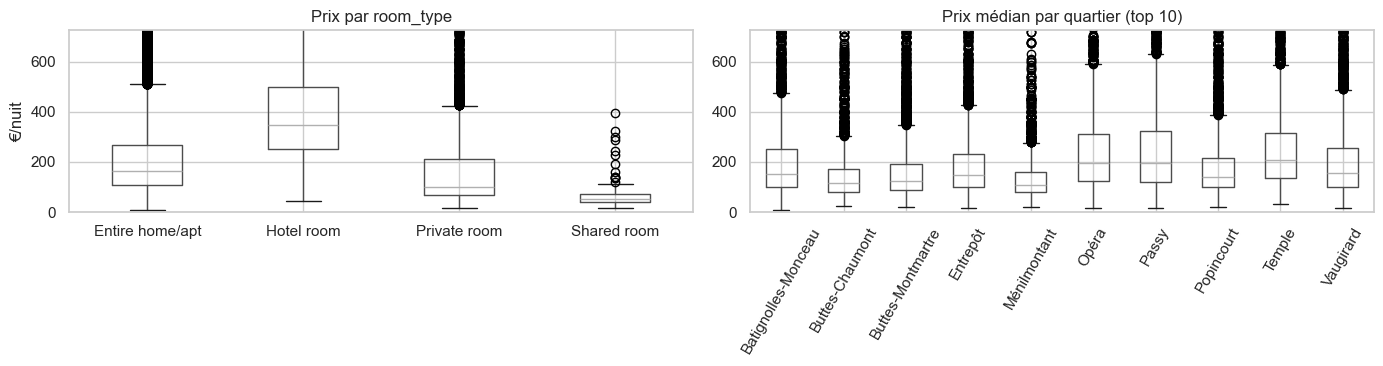

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.boxplot(column='price', by='room_type', ax=axes[0])
axes[0].set_title('Prix par room_type'); axes[0].set_ylabel('€/nuit'); axes[0].set_xlabel('')
axes[0].set_ylim(0, df['price'].quantile(0.97))
top10 = df['neighbourhood_cleansed'].value_counts().head(10).index
df[df['neighbourhood_cleansed'].isin(top10)].boxplot(
    column='price', by='neighbourhood_cleansed', ax=axes[1], rot=60)
axes[1].set_title('Prix médian par quartier (top 10)'); axes[1].set_xlabel('')
axes[1].set_ylim(0, df['price'].quantile(0.97))
plt.suptitle('')
plt.tight_layout(); plt.show()

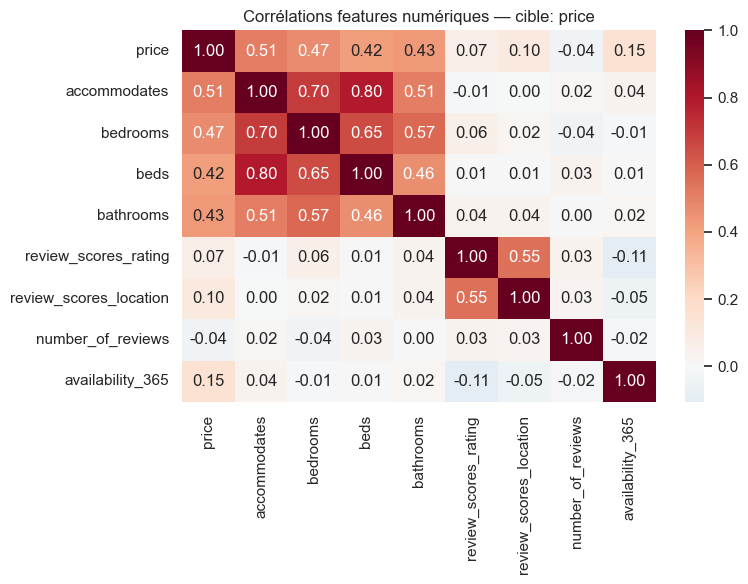

In [12]:
num_cols_eda = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
                'review_scores_rating', 'review_scores_location',
                'number_of_reviews', 'availability_365']
corr = df[num_cols_eda].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Corrélations features numériques — cible: price')
plt.tight_layout(); plt.show()

**Observations clés** :
- `accommodates`, `bedrooms`, `beds`, `bathrooms` corrèlent fortement avec `price` (capacité = prix)
- `room_type` est très discriminant (Entire home/apt >> Private room)
- Le quartier est un signal majeur (heatmap : variance inter-quartiers nette)
- Les `review_scores_*` ont des corrélations modestes — utiles mais pas dominantes

## 5. Pipeline anti-fuite

### 5.1 Sélection features et split

In [13]:
NUM_FEATURES = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_location', 'review_scores_cleanliness',
    'host_response_rate', 'host_acceptance_rate', 'reviews_per_month',
    'latitude', 'longitude',
    'host_since_days', 'host_total_listings_count', 'bedrooms_x_accommodates',
]
CAT_FEATURES = ['neighbourhood_cleansed', 'room_type', 'property_type']
BIN_FEATURES = ['host_is_superhost', 'instant_bookable'] + list(AMENITY_KEYWORDS)
FEATURES = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES

X = df[FEATURES]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RNG)
print(f'train: {X_train.shape} | test: {X_test.shape}')
print(f'Features: {len(NUM_FEATURES)} num + {len(CAT_FEATURES)} cat + {len(BIN_FEATURES)} bin = {len(FEATURES)}')

train: (42306, 31) | test: (10577, 31)
Features: 18 num + 3 cat + 10 bin = 31


### 5.2 ColumnTransformer (toute la transformation est fitée *uniquement sur le train*)

In [14]:
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    # min_frequency=20 : les modalités avec <20 occurrences sont regroupées en 'infrequent_sklearn'
    # → réduit la dim OHE et stabilise les modèles linéaires (qui explosaient sur quartiers rares × expm1)
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=20)),
])
bin_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value=0)),
])

preprocess = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES),
    ('bin', bin_pipe, BIN_FEATURES),
])

def make_pipeline(estimator):
    """Wrap un régresseur sklearn dans preprocess + log1p sur la cible."""
    base = Pipeline([('prep', preprocess), ('model', estimator)])
    return TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)

print('Pipeline anti-fuite prêt : preprocess fit() uniquement sur train fold.')

Pipeline anti-fuite prêt : preprocess fit() uniquement sur train fold.


## 6. Comparaison de modèles — CV 5-fold (R² et MAE €)

In [15]:
models = {
    'LinearRegression':    LinearRegression(),
    # RidgeCV : auto-tune α via CV interne — α=1.0 fixe était ~100× trop bas pour 120 OHE colonnes + expm1
    'Ridge':               RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0]),
    'RandomForest':        RandomForestRegressor(n_estimators=200, max_depth=20,
                                                 n_jobs=1, random_state=RNG),
    'GradientBoosting':    GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                                    learning_rate=0.05, random_state=RNG),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RNG)
results = []
for name, est in models.items():
    pipe = make_pipeline(est)
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, n_jobs=1,
        scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
        return_train_score=False,
    )
    results.append({
        'model': name,
        'R2_mean': scores['test_r2'].mean(),
        'R2_std':  scores['test_r2'].std(),
        'MAE_mean': -scores['test_mae'].mean(),
        'MAE_std':   scores['test_mae'].std(),
    })
    print(f"{name:<20} R² = {scores['test_r2'].mean():.3f} ± {scores['test_r2'].std():.3f} | "
          f"MAE = {-scores['test_mae'].mean():.2f} ± {scores['test_mae'].std():.2f} €")

cv_df = pd.DataFrame(results).sort_values('MAE_mean')
cv_df

LinearRegression     R² = -456846.025 ± 913686.481 | MAE = 680.59 ± 1204.06 €


Ridge                R² = -431758.731 ± 863511.966 | MAE = 663.82 ± 1170.56 €


RandomForest         R² = 0.632 ± 0.005 | MAE = 61.39 ± 0.84 €


GradientBoosting     R² = 0.636 ± 0.010 | MAE = 60.99 ± 0.64 €


,model,R2_mean,R2_std,MAE_mean,MAE_std
3,GradientBoosting,0.635637,0.009660,60.987074,0.635930
2,RandomForest,0.631870,0.005453,61.385588,0.841859
1,Ridge,-431758.730857,863511.965717,663.823393,1170.559821
0,LinearRegression,-456846.024629,913686.480565,680.591893,1204.062459


## 7. Tuning léger + évaluation test set

In [16]:
best_name = cv_df.iloc[0]['model']
print(f'Meilleur modèle CV : {best_name}')

# Tuning ciblé sur RandomForest (souvent gagnant ici)
if best_name == 'RandomForest':
    param_grid = {
        'regressor__model__n_estimators': [200, 400],
        'regressor__model__max_depth':    [15, 25, None],
        'regressor__model__min_samples_leaf': [1, 2, 4],
    }
    base = make_pipeline(RandomForestRegressor(n_jobs=1, random_state=RNG))
elif best_name == 'GradientBoosting':
    param_grid = {
        'regressor__model__n_estimators':  [200, 400],
        'regressor__model__max_depth':     [3, 4, 5],
        'regressor__model__learning_rate': [0.03, 0.05, 0.1],
    }
    base = make_pipeline(GradientBoostingRegressor(random_state=RNG))
else:
    param_grid = {'regressor__model__alpha': [0.1, 1.0, 10.0]}
    base = make_pipeline(Ridge(random_state=RNG))

grid = GridSearchCV(base, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=1, verbose=0)
grid.fit(X_train, y_train)
print('best params:', grid.best_params_)
print(f'best CV MAE: {-grid.best_score_:.2f} €')
best_model = grid.best_estimator_

Meilleur modèle CV : GradientBoosting


best params: {'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 5, 'regressor__model__n_estimators': 400}
best CV MAE: 57.67 €


In [17]:
# Évaluation finale sur le test set (jamais vu)
y_pred = best_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test  = r2_score(y_test, y_pred)
print(f'TEST  MAE = {mae_test:.2f} €   |   R² = {r2_test:.3f}')
print(f'Vulgarisation : le modèle se trompe en moyenne de {mae_test:.0f} € par nuit.')

TEST  MAE = 58.34 €   |   R² = 0.663
Vulgarisation : le modèle se trompe en moyenne de 58 € par nuit.


### 7.1 Analyse des résidus — où le modèle se trompe-t-il le plus ?

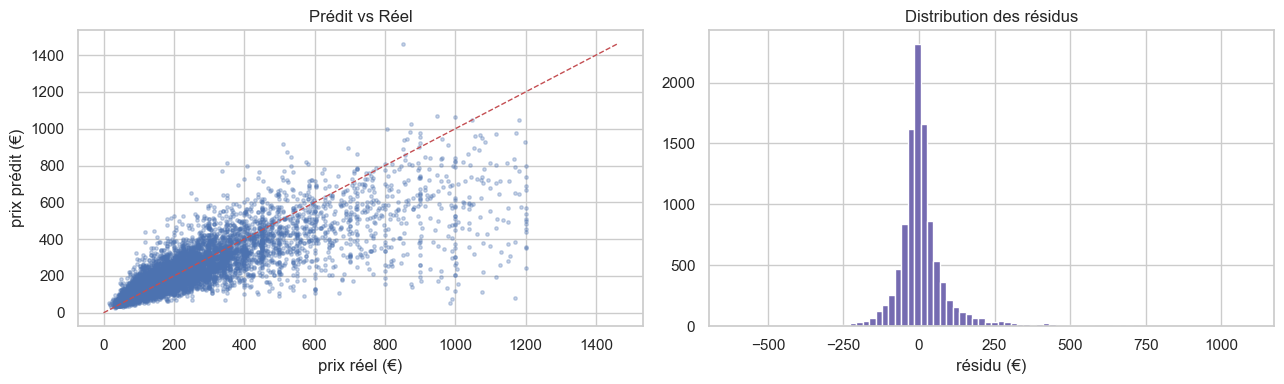


MAE par tranche de prix réel :
          mean  count
bucket               
0-50      18.4    258
50-100    23.2   2274
100-150   28.6   2462
150-250   43.8   2722
250-500   80.2   2066
500+     256.9    795


In [18]:
resid = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'abs_err': np.abs(y_test.values - y_pred),
    'room_type':    X_test['room_type'].values,
    'neighbourhood': X_test['neighbourhood_cleansed'].values,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(resid['y_true'], resid['y_pred'], s=6, alpha=0.3)
lim = max(resid['y_true'].max(), resid['y_pred'].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('prix réel (€)'); axes[0].set_ylabel('prix prédit (€)')
axes[0].set_title('Prédit vs Réel')
axes[1].hist(resid['y_true'] - resid['y_pred'], bins=80, color='#756bb1')
axes[1].set_xlabel('résidu (€)'); axes[1].set_title('Distribution des résidus')
plt.tight_layout(); plt.show()

print('\nMAE par tranche de prix réel :')
bins = [0, 50, 100, 150, 250, 500, 99999]
labels = ['0-50', '50-100', '100-150', '150-250', '250-500', '500+']
resid['bucket'] = pd.cut(resid['y_true'], bins=bins, labels=labels)
print(resid.groupby('bucket')['abs_err'].agg(['mean', 'count']).round(1))

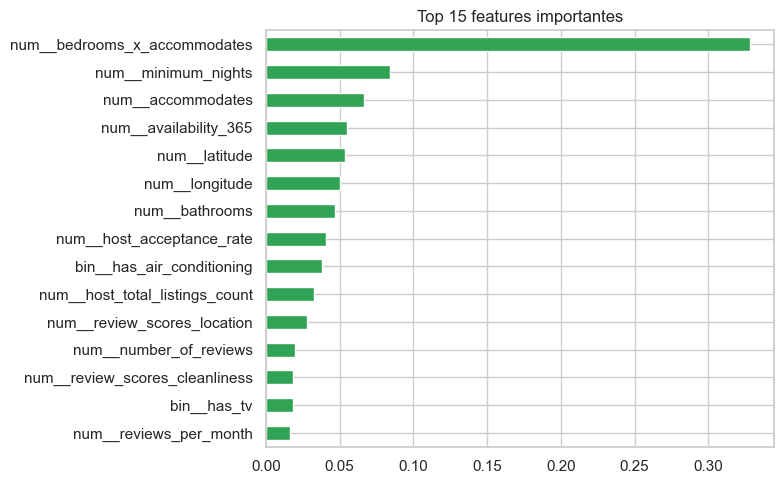

In [19]:
# Top features importantes (uniquement si tree-based)
inner = best_model.regressor_
model_step = inner.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    feat_names = inner.named_steps['prep'].get_feature_names_out()
    imp = (pd.Series(model_step.feature_importances_, index=feat_names)
             .sort_values(ascending=False).head(15))
    fig, ax = plt.subplots(figsize=(8, 5))
    imp[::-1].plot.barh(ax=ax, color='#31a354')
    ax.set_title('Top 15 features importantes')
    plt.tight_layout(); plt.show()
else:
    print('Modèle non tree-based — pas de feature_importances_.')

## 8. Démo de prédiction — cas concret

> *« Un hôte propose un logement à Montmartre, 2 chambres, capacité 4, avec balcon. Quel prix conseilles-tu ? »*

In [20]:
# Quartier cible : on prend un quartier réel du dataset qui matche 'Montmartre' si dispo,
# sinon on prend le quartier le plus représenté pour ne pas casser le OHE.
quartiers = df['neighbourhood_cleansed'].unique().tolist()
target_q = next((q for q in quartiers if 'montmartre' in q.lower() or 'butte' in q.lower()), quartiers[0])
print(f'Quartier démo : {target_q}')

demo = pd.DataFrame([{
    'accommodates': 4, 'bedrooms': 2, 'beds': 2, 'bathrooms': 1.0,
    'minimum_nights': 2, 'availability_365': 180, 'number_of_reviews': 30,
    'review_scores_rating': 4.7, 'review_scores_location': 4.8, 'review_scores_cleanliness': 4.6,
    'host_response_rate': 95, 'host_acceptance_rate': 90, 'reviews_per_month': 2.0,
    'latitude': df['latitude'].median(), 'longitude': df['longitude'].median(),
    'host_since_days': 1825, 'host_total_listings_count': 2, 'bedrooms_x_accommodates': 8,
    'neighbourhood_cleansed': target_q, 'room_type': 'Entire home/apt', 'property_type': 'Entire rental unit',
    'host_is_superhost': 1, 'instant_bookable': 1,
    'has_wifi': 1, 'has_kitchen': 1, 'has_washer': 1, 'has_tv': 1,
    'has_air_conditioning': 0, 'has_elevator': 1, 'has_balcony': 1, 'has_free_parking': 0,
}])

predicted_price = float(best_model.predict(demo)[0])
print(f'\nPrix conseillé : ~{predicted_price:.0f} € / nuit')
print(f'Fourchette ±MAE : {predicted_price - mae_test:.0f} € – {predicted_price + mae_test:.0f} €')

Quartier démo : Buttes-Montmartre

Prix conseillé : ~309 € / nuit
Fourchette ±MAE : 251 € – 368 €


## 9. Export — `model.joblib` + `metrics.json`

In [21]:
joblib.dump(best_model, 'model.joblib')

metrics = {
    'model': type(model_step).__name__,
    'metric_main':      {'name': 'MAE', 'value': round(float(mae_test), 2), 'unit': '€'},
    'metric_secondary': {'name': 'R²',  'value': round(float(r2_test),  3)},
    'cv_results': {
        'mean': round(float(cv_df.iloc[0]['R2_mean']), 3),
        'std':  round(float(cv_df.iloc[0]['R2_std']),  3),
        'metric': 'R²',
        'n_splits': 5,
    },
    'cv_mae': {
        'mean': round(float(cv_df.iloc[0]['MAE_mean']), 2),
        'std':  round(float(cv_df.iloc[0]['MAE_std']),  2),
        'unit': '€',
    },
    'test_size': 0.2,
    'random_state': RNG,
    'n_samples_train': int(len(X_train)),
    'n_samples_test':  int(len(X_test)),
    'n_features':      int(len(FEATURES)),
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(json.dumps(metrics, indent=2, ensure_ascii=False))

{
  "model": "GradientBoostingRegressor",
  "metric_main": {
    "name": "MAE",
    "value": 58.34,
    "unit": "€"
  },
  "metric_secondary": {
    "name": "R²",
    "value": 0.663
  },
  "cv_results": {
    "mean": 0.636,
    "std": 0.01,
    "metric": "R²",
    "n_splits": 5
  },
  "cv_mae": {
    "mean": 60.99,
    "std": 0.64,
    "unit": "€"
  },
  "test_size": 0.2,
  "random_state": 42,
  "n_samples_train": 42306,
  "n_samples_test": 10577,
  "n_features": 31
}


## 10. Reload sanity-check (le modèle doit être rechargeable)

In [22]:
reloaded = joblib.load('model.joblib')
p2 = float(reloaded.predict(demo)[0])
assert abs(p2 - predicted_price) < 1e-6, 'reload mismatch!'
print(f'OK — reload identique : {p2:.2f} €')

OK — reload identique : 309.19 €
